In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Predictive Model for Car Prices

## Introduction

Welcome to this comprehensive notebook dedicated to the creation of a robust predictive model for car prices through the application of advanced machine learning techniques. The automotive industry is dynamic and influenced by a myriad of factors, making accurate pricing a challenging yet crucial aspect for both buyers and sellers. This notebook aims to address this challenge by developing a model that can effectively predict car prices based on a rich dataset encompassing a diverse range of car features and their associated values.

### The Significance of Predictive Modeling in the Automotive Industry

As the automotive landscape evolves, so do the variables influencing car prices. Factors such as make, model, year, mileage, fuel type, and various other specifications contribute to the intricate web of considerations that determine a car's value. Predictive modeling offers a powerful solution to navigate through this complexity, providing insights into the potential price of a vehicle based on its characteristics.

### Objective

The primary objective of this notebook is to leverage machine learning algorithms to train a predictive model capable of accurately estimating car prices. The model's foundation lies in a carefully curated dataset, sourced to capture the nuances of the automotive market comprehensively. By analyzing and understanding patterns within this data, the model aims to generalize its learnings to make accurate predictions on unseen data, offering practical value for pricing decisions in real-world scenarios.

### Why Car Price Prediction Matters

Accurate predictions of car prices have significant implications for various stakeholders. For prospective buyers, it provides insights into fair market values and aids in informed decision-making. For sellers, including dealerships and individual sellers, it assists in setting competitive yet reasonable prices, optimizing sales, and maintaining profitability. Moreover, financial institutions and insurance companies can benefit from precise valuation for loan approvals and premium calculations.

### Methodology

The journey towards achieving an effective predictive model involves several key stages, including data collection, exploration, preprocessing, feature engineering, model selection, training, evaluation, and potential deployment. Each of these stages is meticulously addressed in the subsequent sections of this notebook, with the aim of providing a transparent and replicable methodology.

As we delve into the intricacies of building this predictive model, it's important to keep in mind the real-world applications and implications of accurate car price predictions. The success of the model will not only be measured by its performance metrics but also by its practical utility and relevance in the automotive industry.



# Data Collection

In this section, we embark on the crucial process of collecting and preparing the dataset for our car price prediction model

## Understanding the Dataset

The selected dataset from Kaggle is a curated collection of information encompassing various features related to cars and their corresponding prices. This dataset aligns seamlessly with our goal of building a predictive model to estimate car prices based on diverse attributes. Before delving into the intricacies of the modeling process, it is imperative to first understand the structure and characteristics of the dataset.

## Loading the Kaggle Dataset

To begin, we utilize the powerful `pandas` library to load the dataset into our Python notebook. This step is instrumental in gaining access to the raw data, setting the stage for exploration and analysis.


In [2]:
df = pd.read_csv("/kaggle/input/car-price-prediction-challenge/car_price_prediction.csv" , sep=",")
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


# Data Exploration and Preprocessing
This section encompasses the exploration of the dataset's structure. Procedures are implemented to handle missing values and preprocess features, ensuring their suitability for input into the predictive model. Tasks may include converting categorical variables, managing missing data, and normalizing numerical features.


## 1. Explore Dataset Structure


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [4]:
df.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


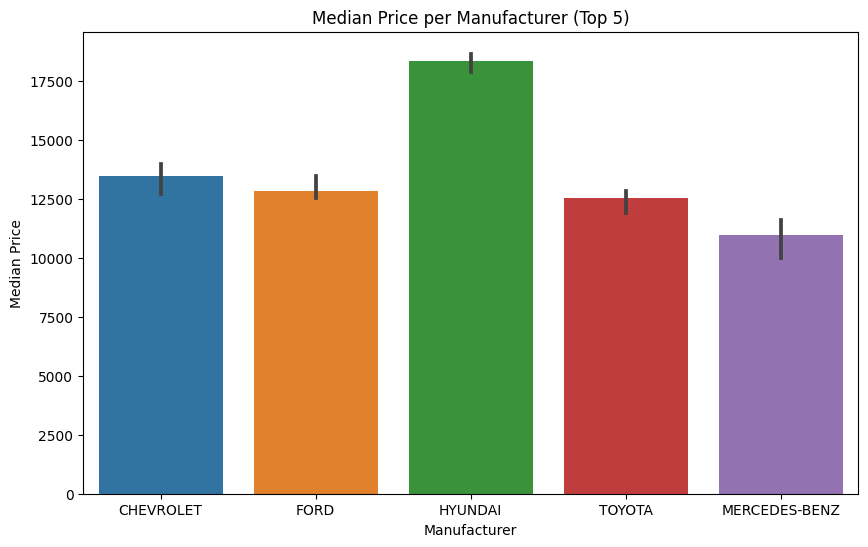

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


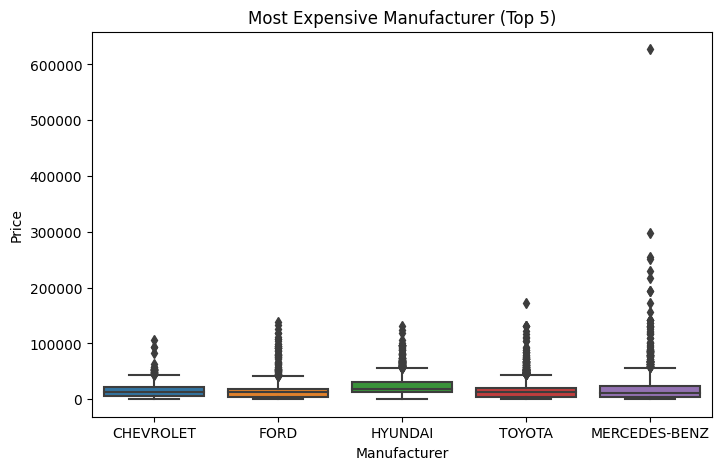

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

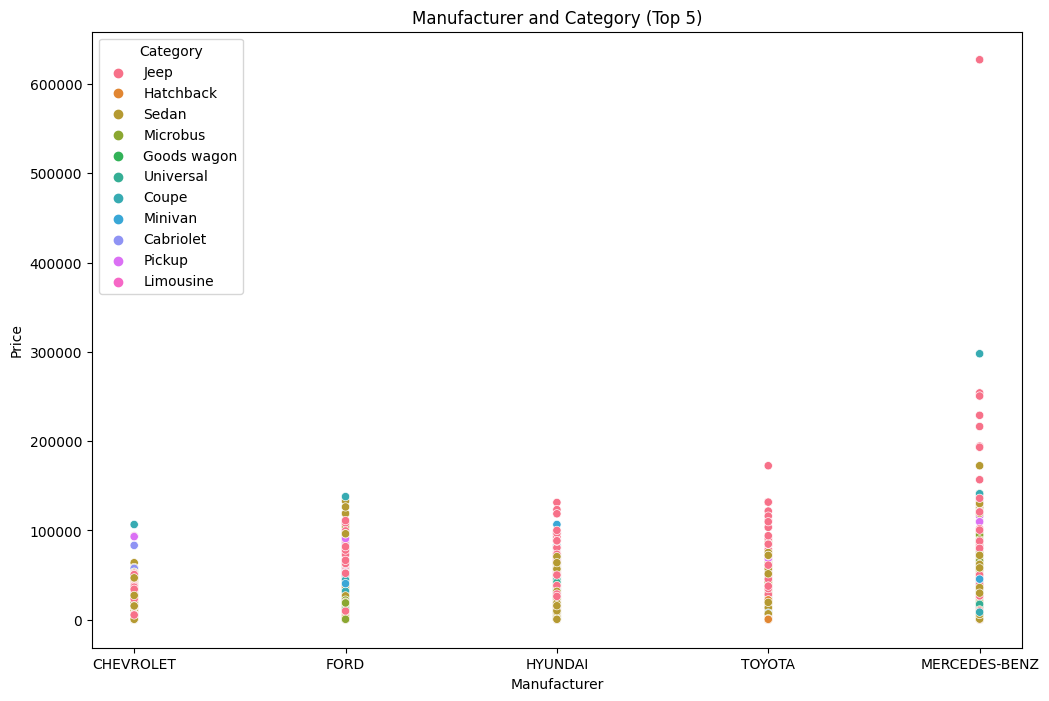

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


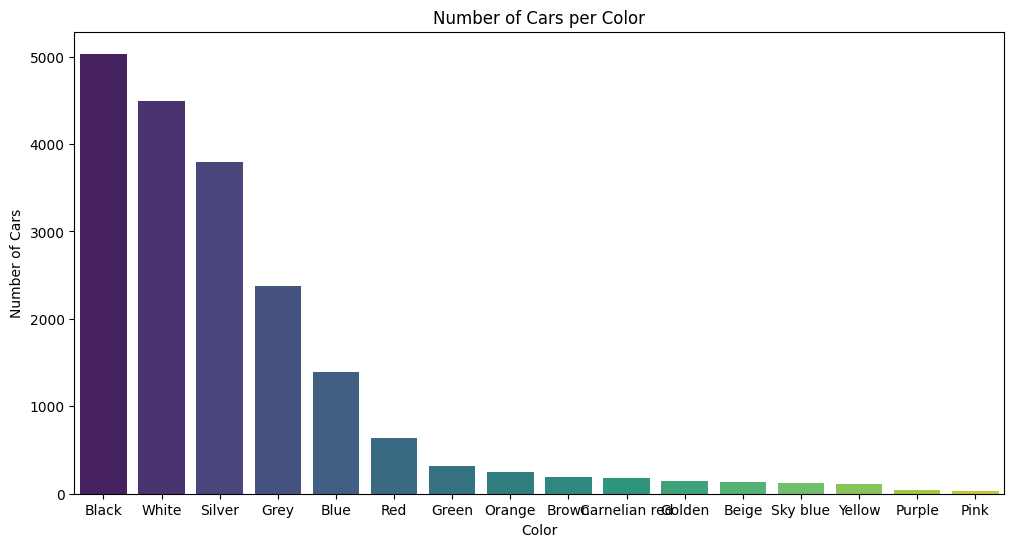

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


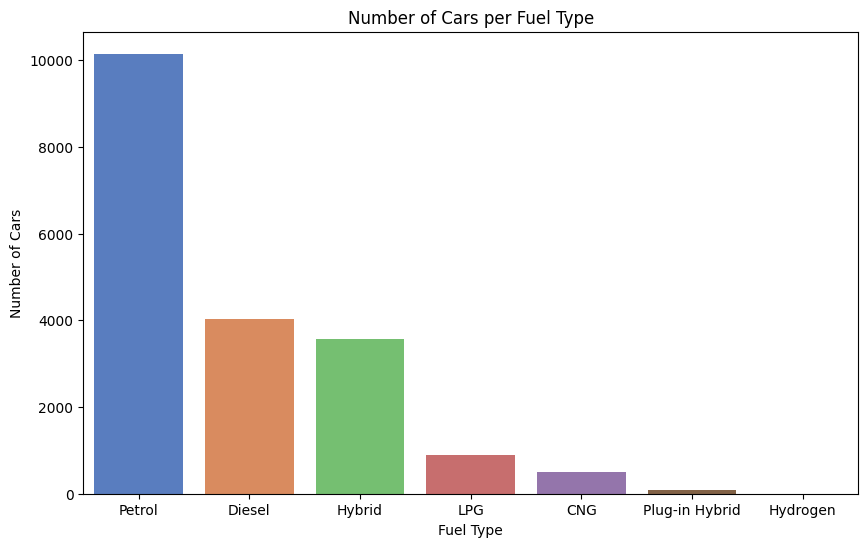

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


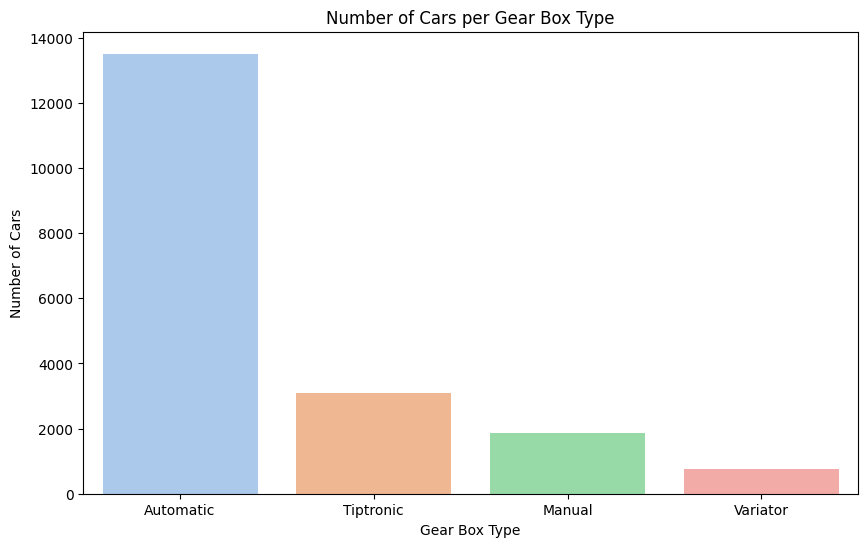

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


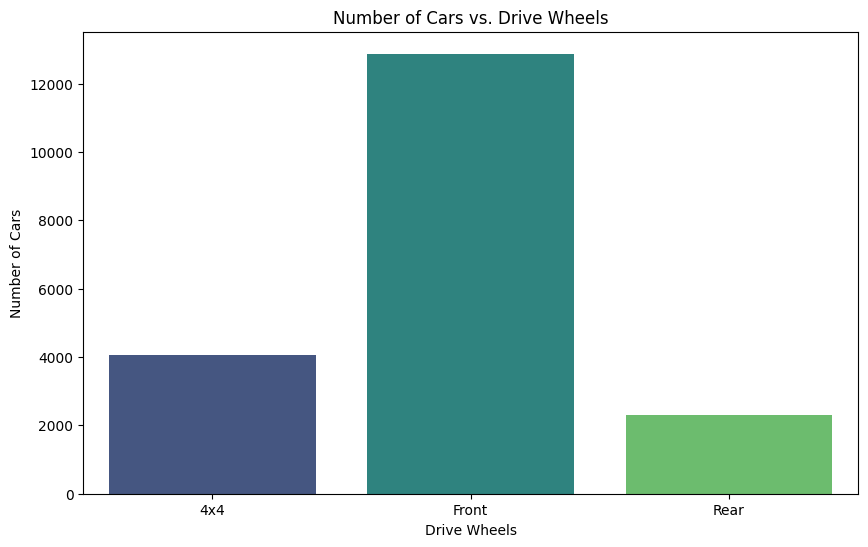

In [5]:
top_manufacturers = df['Manufacturer'].value_counts().nlargest(5).index

# Plot 1: Median Price per Manufacturer (Top 5)
plt.figure(figsize=(10, 6))
sns.barplot(x='Manufacturer', y='Price', data=df[df['Manufacturer'].isin(top_manufacturers)], estimator='median')
plt.title('Median Price per Manufacturer (Top 5)')
plt.xlabel('Manufacturer')
plt.ylabel('Median Price')
plt.show()

# Plot 3: Most Expensive Manufacturer (Top 5)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Manufacturer', y='Price', data=df[df['Manufacturer'].isin(top_manufacturers)])
plt.title('Most Expensive Manufacturer (Top 5)')
plt.xlabel('Manufacturer')
plt.ylabel('Price')
plt.show()

# Plot 5: Manufacturer and Category (Top 5)
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Manufacturer', y='Price', hue='Category', data=df[df['Manufacturer'].isin(top_manufacturers)])
plt.title('Manufacturer and Category (Top 5)')
plt.xlabel('Manufacturer')
plt.ylabel('Price')
plt.legend(title='Category')
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(x='Color', data=df, order=df['Color'].value_counts().index, palette='viridis')
plt.title('Number of Cars per Color')
plt.xlabel('Color')
plt.ylabel('Number of Cars')
plt.show()

# Plot: Number of Cars per Fuel Type with Legend
plt.figure(figsize=(10, 6))
sns.countplot(x='Fuel type', data=df, order=df['Fuel type'].value_counts().index, palette='muted')
plt.title('Number of Cars per Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.show()

# Plot: Number of Cars per Gear Box Type
plt.figure(figsize=(10, 6))
sns.countplot(x='Gear box type', data=df, order=df['Gear box type'].value_counts().index, palette='pastel')
plt.title('Number of Cars per Gear Box Type')
plt.xlabel('Gear Box Type')
plt.ylabel('Number of Cars')
plt.show()

# Plot 2: Number of Cars vs. Drive Wheels
plt.figure(figsize=(10, 6))
sns.countplot(x='Drive wheels', data=df, palette='viridis')
plt.title('Number of Cars vs. Drive Wheels')
plt.xlabel('Drive Wheels')
plt.ylabel('Number of Cars')
plt.show()


## 2 . Handling Missing Values
Deciding on a strategy to handle missing values is crucial. Common approaches include imputation or removal of rows/columns with missing values.

#### Imputation

Imputation involves filling missing values with calculated or estimated values. Examples include mean or median imputation and forward or backward fill.

In [6]:
df.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

If the output shows zeros for all columns, it indicates that there are no missing values in your dataset.
While your current dataset may not have missing values, it's good practice to include these discussions in your notebook to address potential scenarios in real-world datasets where missing values are common

## 3 Remove Duplicated Rows

### Importance of Removing Duplications in a Dataset

Removing duplications in a dataset is crucial for various reasons:

#### 1. Data Quality:

Duplicated rows may introduce noise and inaccuracies in your analysis, leading to incorrect insights and conclusions. Cleaning duplicate data improves the overall quality of the dataset.

#### 2. Accuracy of Descriptive Statistics:

Descriptive statistics, such as mean, median, and standard deviation, can be influenced by duplicated rows. Removing duplicates ensures that these statistics accurately reflect the underlying data distribution.

#### 3. Model Performance:

When building predictive models, duplicated data can impact the performance of the model. Models may become biased toward the duplicated patterns, leading to overfitting and reduced generalization on new data.

#### 4. Resource Efficiency:

Duplicated rows increase the size of the dataset without providing additional information. By removing duplicates, you can make better use of computational resources and storage space.

#### 5. Data Integrity:

Duplicate entries can compromise the integrity of the dataset, especially if there are conflicting values for the same entity. Ensuring data integrity is crucial for making reliable and informed decisions.

#### 6. Avoiding Redundancy:

Duplicates often represent redundant information, contributing little to the overall understanding of the dataset. Eliminating redundancy simplifies data exploration and analysis.

#### 7. Consistent Analysis:

Removing duplicates ensures that your analysis is consistent and unbiased. It helps in generating accurate and reliable results, whether you are conducting exploratory data analysis or building machine learning models.


In [7]:
duplicates_id = df.duplicated(subset='ID', keep=False)
duplicated_rows = df[duplicates_id]
duplicated_rows_sorted = duplicated_rows.sort_values(by='ID')
duplicated_rows_sorted

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
5754,35464629,7840,1111,HONDA,FIT,2012,Hatchback,No,Petrol,1.3,108000 km,4.0,Automatic,Front,04-May,Right-hand drive,Blue,6
7269,35464629,7840,1111,HONDA,FIT,2012,Hatchback,No,Petrol,1.3,108000 km,4.0,Automatic,Front,04-May,Right-hand drive,Blue,6
1107,36559154,19726,-,MERCEDES-BENZ,Sprinter 411,2002,Goods wagon,No,Diesel,2.2 Turbo,280000 km,4.0,Manual,Rear,02-Mar,Left wheel,White,2
6732,36559154,19726,-,MERCEDES-BENZ,Sprinter 411,2002,Goods wagon,No,Diesel,2.2 Turbo,280000 km,4.0,Manual,Rear,02-Mar,Left wheel,White,2
9990,41770767,11917,-,NISSAN,Murano,2004,Jeep,Yes,CNG,3.5,233600 km,6.0,Variator,4x4,04-May,Left wheel,Silver,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15880,45815564,9408,-,MERCEDES-BENZ,E 240,2000,Sedan,No,Petrol,2.4,252000 km,6.0,Manual,Rear,04-May,Left wheel,Black,4
14469,45815994,4077,751,HYUNDAI,Sonata,2013,Sedan,Yes,Petrol,2.4,111930 km,4.0,Automatic,Front,04-May,Left wheel,Silver,12
3756,45815994,4077,751,HYUNDAI,Sonata,2013,Sedan,Yes,Petrol,2.4,111930 km,4.0,Automatic,Front,04-May,Left wheel,Silver,12
8730,45816384,49237,730,HYUNDAI,Tucson,2016,Jeep,Yes,Petrol,1.6,27000 km,4.0,Tiptronic,4x4,04-May,Left wheel,White,12


In [8]:
df_no_duplicates_id = df.drop_duplicates(subset='ID')
df = df_no_duplicates_id
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


## 4. Manage Outliers:

Managing outliers is an important step in the analysis and statistical modeling to ensure that extreme values do not unduly influence the results. Outliers are data points that significantly differ from the rest of the dataset and can skew statistical measures.

In this notebook, we will address the presence of outlier records in the dataset by remove record that holds the outlier. It's important to note that there are various approaches to handle outliers, each with its own advantages and considerations. Here are several methods for handling outliers:

- Winsorizing or Truncation
- Log Transformation
- Robust Scaling
- IQR (Interquartile Range) Method
- Z-Score Method
- Remove Entire Records 
- Data Transformation
- Imputation

In [9]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numerical_columns] < (Q1 - 1.5 * IQR)) | (df[numerical_columns] > (Q3 + 1.5 * IQR))).any(axis=1)
df = df[~outliers]
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,45802912,39493,891,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931 km,4.0,Automatic,Front,04-May,Left wheel,White,4
6,45656768,1803,761,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909 km,4.0,Automatic,Front,04-May,Left wheel,White,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19230,45760891,470,645,TOYOTA,Prius,2011,Hatchback,Yes,Hybrid,1.8,307325 km,4.0,Automatic,Front,04-May,Left wheel,Silver,12
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.u

Text(0.5, 1.0, 'Histogram of Price')

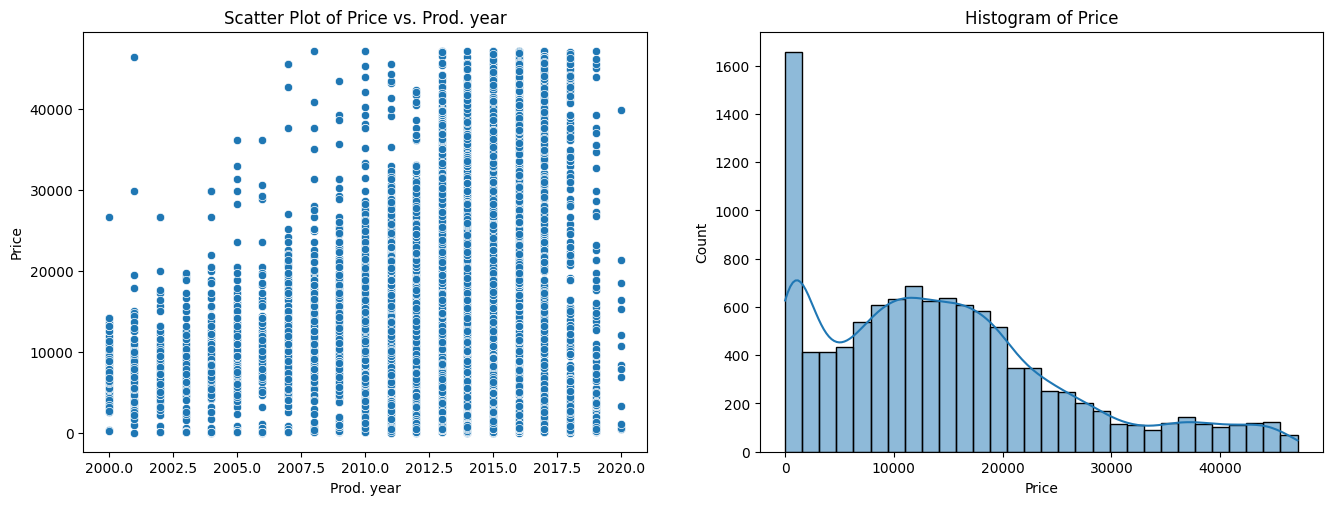

In [10]:
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.scatterplot(x='Prod. year', y='Price', data=df)
plt.title('Scatter Plot of Price vs. Prod. year')

plt.subplot(2, 2, 2)
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('Histogram of Price')


## Feature Engineering
Feature engineering techniques are demonstrated in this section, aiming to augment the predictive power of the model. New features are created or existing ones are transformed to enhance the model's ability to capture intricate patterns.

In [11]:
df['Mileage'] = df['Mileage'].str.replace('km', '')

df['Mileage'] = df['Mileage'].astype(int)

df

/tmp/ipykernel_51/3476073254.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Mileage'] = df['Mileage'].str.replace('km', '')
/tmp/ipykernel_51/3476073254.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Mileage'] = df['Mileage'].astype(int)


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,45802912,39493,891,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931,4.0,Automatic,Front,04-May,Left wheel,White,4
6,45656768,1803,761,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909,4.0,Automatic,Front,04-May,Left wheel,White,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19230,45760891,470,645,TOYOTA,Prius,2011,Hatchback,Yes,Hybrid,1.8,307325,4.0,Automatic,Front,04-May,Left wheel,Silver,12
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258,4.0,Automatic,Front,04-May,Left wheel,Black,4


In [12]:
def categorize_milage(milage):
    if milage < 100000:
        return 'Low'
    elif 100000 <= milage <= 300000:
        return 'Medium'
    else:
        return 'High'

df['Mileage_Category'] = df['Mileage'].apply(categorize_milage)


/tmp/ipykernel_51/1041030558.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Mileage_Category'] = df['Mileage'].apply(categorize_milage)


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


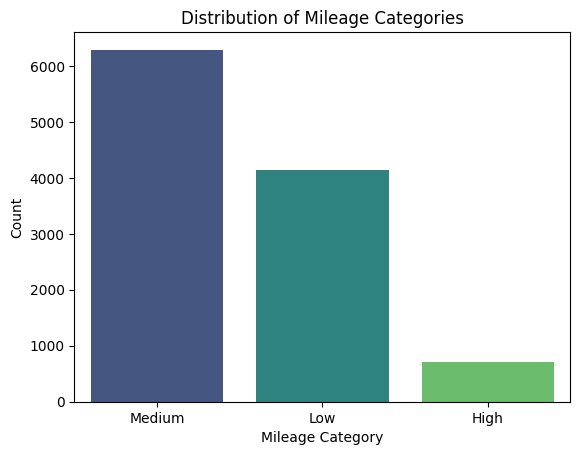

In [13]:
sns.countplot(x='Mileage_Category', data=df, palette='viridis')
plt.xlabel('Mileage Category')
plt.ylabel('Count')
plt.title('Distribution of Mileage Categories')
plt.show()

In [14]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

ordinal_encoder = OrdinalEncoder()

encoded_data = ordinal_encoder.fit_transform(df[categorical_columns])

df[categorical_columns] = encoded_data.astype(int)

df.head()

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtyp

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Mileage_Category
2,45774419,8467,0,17,313,2006,3,0,4,13,200000,4.0,3,1,1,1,1,2,2
3,45769185,3607,308,13,303,2011,4,1,2,36,168966,4.0,0,0,1,0,14,0,2
4,45809263,11726,181,17,313,2014,3,1,4,13,91901,4.0,0,1,1,0,12,4,1
5,45802912,39493,321,18,609,2016,4,1,1,27,160931,4.0,0,1,1,0,14,4,2
6,45656768,1803,280,44,556,2010,3,1,2,23,258909,4.0,0,1,1,0,14,12,2


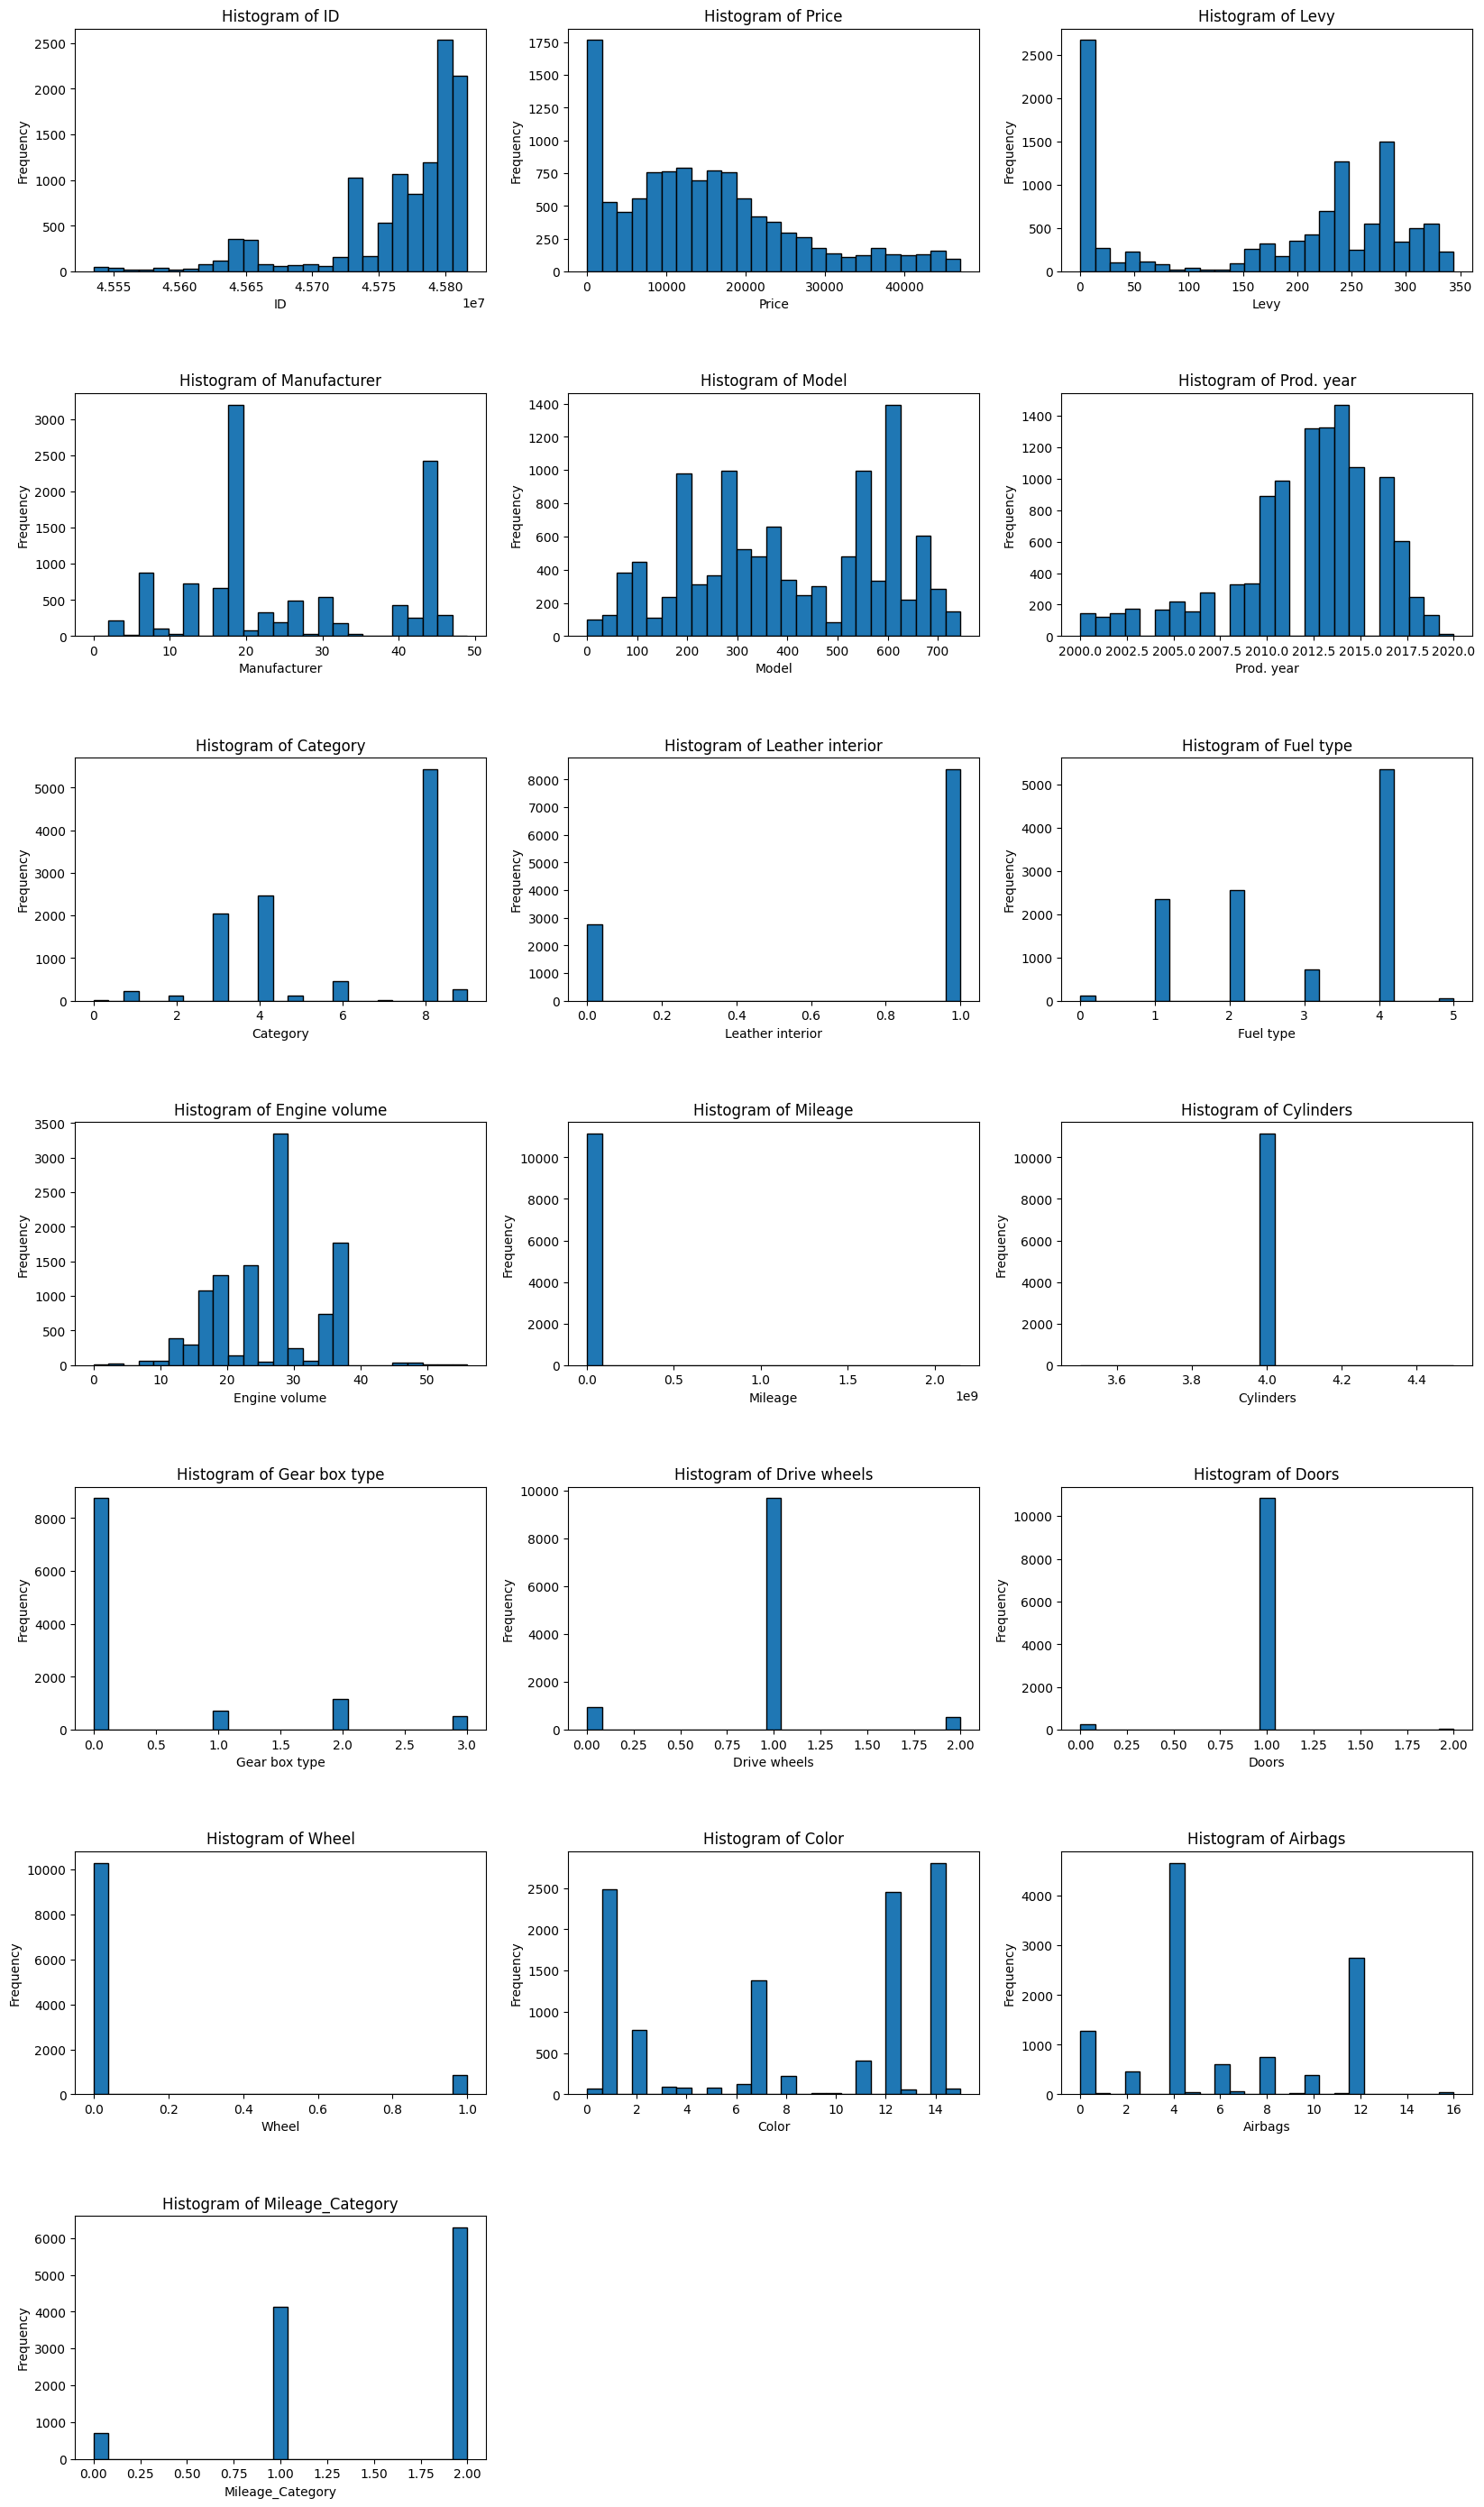

In [15]:
all_columns = df.columns

num_cols = len(all_columns)
num_rows = (num_cols - 1) // 3 + 1  

fig, axes = plt.subplots(num_rows, 3, figsize=(20, 5 * num_rows))
fig.subplots_adjust(hspace=0.5)  

axes = axes.flatten()

for i, column in enumerate(all_columns):
    axes[i].hist(df[column], bins=25, edgecolor='black')
    axes[i].set_title(f'Histogram of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

for i in range(num_cols, len(axes)):
    fig.delaxes(axes[i])

plt.show()

## Feature Selection

#### Importance of Correlation in Feature Selection

Correlation plays a vital role in feature selection for the following reasons:

1. **Identifying Redundant Features:**
   Highly correlated features carry similar information, leading to redundancy. Removing correlated features simplifies the model without sacrificing predictive power.

2. **Multicollinearity Detection:**
  Detecting multicollinearity through correlation analysis ensures stable model coefficients and interpretable results.

3. **Improving Model Interpretability:**
  Lower intercorrelation between features enhances the interpretability of model coefficients.

4. **Enhancing Model Performance:**
  Selecting a subset of less correlated features can contribute to a more efficient and accurate model.

5. **Avoiding Overfitting:**
   Removing highly correlated features reduces the risk of overfitting and promotes better generalization.

6. **Efficient Computation:**
   Reducing dimensionality by removing highly correlated features speeds up model training and prediction.

7. **Feature Importance:**
  Understanding feature correlation aids in interpreting feature importance scores in machine learning models.

Correlation analysis is crucial for efficient and effective feature selection in machine learning models.


In [16]:
correlation_matrix = df.corr()
correlation_matrix

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Mileage_Category
ID,1.000000,0.121260,-0.021920,-0.202398,0.038350,-0.048608,-0.040406,0.047939,0.053275,-0.050714,0.000452,NaN,-0.042903,0.065836,-0.024954,-0.004278,0.020554,-0.058517,-0.011659
Price,0.121260,1.000000,0.063170,-0.065055,0.069072,0.270742,-0.085740,0.057661,-0.208867,0.109495,-0.004457,NaN,0.060660,0.058355,0.027627,-0.152240,0.039265,-0.166779,-0.018131
Levy,-0.021920,0.063170,1.000000,-0.131242,0.046885,0.415798,0.112816,0.436970,-0.041667,0.071754,-0.020528,NaN,-0.308623,-0.001672,0.119923,-0.390754,0.038098,0.022635,-0.088643
Manufacturer,-0.202398,-0.065055,-0.131242,1.000000,-0.027201,-0.095933,-0.087245,-0.186275,-0.064111,0.081693,0.008570,NaN,0.118082,-0.086276,0.033884,0.093919,0.005064,0.255273,0.032267
Model,0.038350,0.069072,0.046885,-0.027201,1.000000,-0.038869,-0.115240,-0.029890,-0.171514,0.015708,0.017824,NaN,-0.028007,-0.067009,0.039443,-0.032557,0.076904,-0.147243,-0.022889
Prod. year,-0.048608,0.270742,0.415798,-0.095933,-0.038869,1.000000,0.189071,0.432313,0.063471,0.098210,-0.025579,NaN,-0.233371,-0.012477,0.133137,-0.394894,-0.035632,0.213756,-0.219824
Category,-0.040406,-0.085740,0.112816,-0.087245,-0.115240,0.189071,1.000000,0.147541,0.178031,0.236452,-0.003175,NaN,-0.048615,0.110772,0.179151,-0.163049,-0.032630,0.161025,-0.107658
Leather interior,0.047939,0.057661,0.436970,-0.186275,-0.029890,0.432313,0.147541,1.000000,-0.064273,0.199867,-0.032493,NaN,-0.397639,0.021483,0.092552,-0.386467,-0.020584,0.041415,-0.121197
Fuel type,0.053275,-0.208867,-0.041667,-0.064111,-0.171514,0.063471,0.178031,-0.064273,1.000000,-0.151692,-0.010577,NaN,0.098993,-0.132625,-0.031990,0.102933,-0.111616,0.163478,-0.072814
Engine volume,-0.050714,0.109495,0.071754,0.081693,0.015708,0.098210,0.236452,0.199867,-0.151692,1.000000,0.003701,NaN,-0.077626,-0.046332,0.055229,-0.234685,-0.036218,0.170566,-0.008269


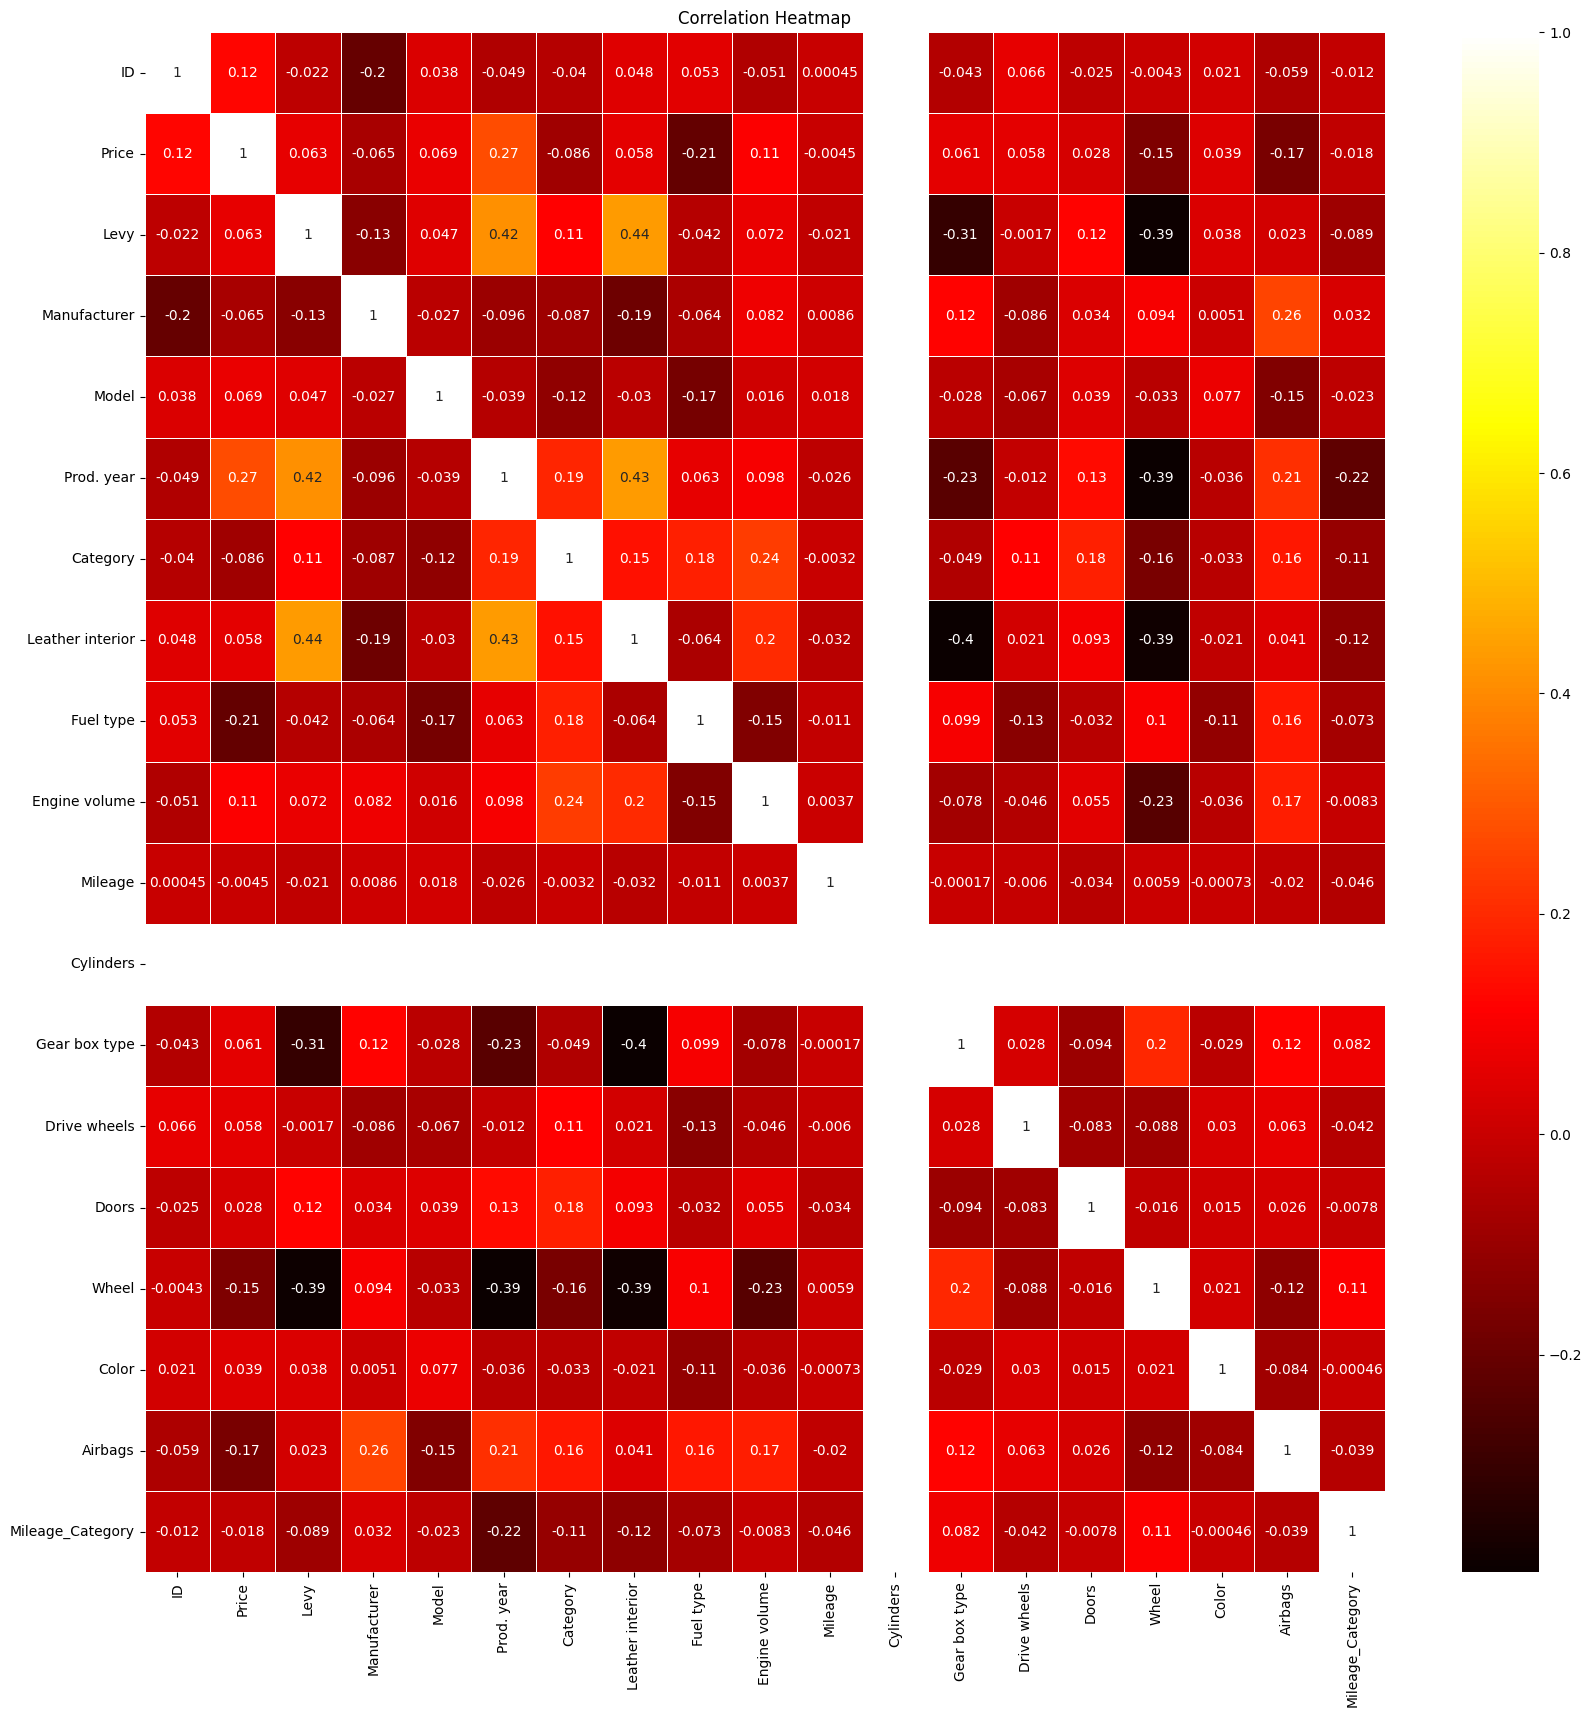

In [17]:
plt.figure(figsize=(20,20))
sns.heatmap(correlation_matrix, annot= True, linewidths= 0.5,cmap='hot')
plt.title('Correlation Heatmap')
plt.show()

In [18]:
price_correlations = correlation_matrix['Price'].drop('Price')
price_correlations_without_nan = price_correlations.dropna()
print("Correlations with Price (after dropping NaNs):")
print(price_correlations_without_nan)


Correlations with Price (after dropping NaNs):
ID                  0.121260
Levy                0.063170
Manufacturer       -0.065055
Model               0.069072
Prod. year          0.270742
Category           -0.085740
Leather interior    0.057661
Fuel type          -0.208867
Engine volume       0.109495
Mileage            -0.004457
Gear box type       0.060660
Drive wheels        0.058355
Doors               0.027627
Wheel              -0.152240
Color               0.039265
Airbags            -0.166779
Mileage_Category   -0.018131
Name: Price, dtype: float64


### Feature Correlations with Price

#### Positive Correlations with Price:

1. **Prod. year:** There is a moderate positive correlation (0.27) with the production year, suggesting that newer cars tend to have higher prices.
2. **Leather interior:** A weak positive correlation (0.058) indicates that cars with leather interiors may have slightly higher prices.
3. **Engine volume:** A weak positive correlation (0.109) suggests that cars with larger engine volumes might have higher prices.
4. **Gear box type:** A weak positive correlation (0.061) indicates that certain types of gearboxes might be associated with higher prices.

#### Negative Correlations with Price:

1. **Fuel type:** A moderate negative correlation (-0.21) suggests that certain fuel types might be associated with lower prices.
2. **Wheel:** A moderate negative correlation (-0.152) suggests that certain types of wheels might be associated with lower prices.

#### Weak Correlations with Price:

1. **ID:** A very weak positive correlation (0.121) with the price.
2. **Levy:** A very weak positive correlation (0.063) with the price.
3. **Manufacturer:** A very weak negative correlation (-0.065) with the price.
4. **Model:** A very weak positive correlation (0.069) with the price.
5. **Category:** A very weak negative correlation (-0.086) implies that certain categories may be associated with lower prices.
6. **Mileage:** A very weak negative correlation (-0.004) with the price.
7. **Cylinders:** No correlation (NaN) with the price.
8. **Drive wheels:** A very weak positive correlation (0.058) with the price.
9. **Doors:** A very weak positive correlation (0.028) with the price.
10. **Color:** A very weak positive correlation (0.039) with the price.
11. **Airbags:** A moderate negative correlation (-0.167) with the price.
12. **Mileage_Category:** A very weak negative correlation (-0.018) with the price.

These correlations provide insights into the relationships between various features and the car prices. It's important to note that correlation does not imply causation, and additional analysis may be required to understand the underlying factors influencing car prices.



## Data spliting

### Importance of Data Splitting 

Data splitting is crucial in machine learning for the following reasons:

1. **Training and Testing Separation:**
   Dividing the dataset into training and testing sets allows model training on one subset and evaluation on another, providing a realistic assessment of model performance.

2. **Model Generalization:**
   Testing on unseen data helps assess how well the model generalizes to new, real-world observations, ensuring it performs well beyond the training set.

3. **Overfitting Prevention:**
   Data splitting helps detect and prevent overfitting by evaluating the model's performance on data it hasn't seen during training.

4. **Model Selection:**
   It facilitates the comparison of different models by evaluating their performance on the same testing set, aiding in the selection of the best-performing model.

5. **Parameter Tuning:**
   Splitting data enables fine-tuning of model parameters without introducing bias, as the testing set provides an unbiased evaluation of model performance.

6. **Trustworthy Evaluation Metrics:**
   By using a separate testing set, the evaluation metrics (e.g., accuracy, precision, recall) provide a reliable indication of the model's real-world effectiveness.

7. **Reproducibility:**
   Setting a random seed ensures reproducibility, allowing consistent results during different runs of the model development process.

8. **Assessment of Model Robustness:**
   Testing on different subsets of the data helps assess the model's robustness by evaluating its performance under various conditions.

Data splitting is a fundamental step that ensures the reliability, generalization, and effectiveness of machine learning models.


In [19]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Selection - Training - Evaluation

This section is designed to automate the process of selecting and training machine learning models. It typically involves exploring multiple models and evaluating their performance to identify the most suitable one for then given use case . This code segment initializes a set of models, such as Random Forest, Linear Regression, Gradient Boosting, Ridge Regression, Lasso Regression, and Decision Tree. It then trains each model on a training dataset, paving the way for subsequent evaluation and comparison of their predictive capabilities. The objective is to streamline the model selection process by automating training procedures, allowing for efficient exploration of different algorithms to find the most effective one for the specific problem at hand.

### Evaluation Metrics:
For each model and fold, I calculate two key metrics:
- **Mean Squared Error (MSE)**: Measures the average squared difference between predicted and actual values. Lower MSE indicates better predictive accuracy.
- **R-squared (R^2) Score**: Measures the proportion of variance in the target variable explained by the model. Higher R^2 scores indicate better explanatory power.

## Results:
I present the mean and standard deviation of MSE and R^2 scores for each model after cross-validation. These scores help in assessing the overall performance and variability of each model.

By comparing the performance of these three models using cross-validation, I aim to identify the best-performing model for the regression task at hand. This information can guide model selection and decision-making in real-world applications.

In [20]:
models = [
    ('Random Forest', RandomForestRegressor()),
    ('Linear Regression', LinearRegression()),
    ('Gradient Boosting', GradientBoostingRegressor()),
    ('Ridge Regression', Ridge()),
    ('Lasso Regression', Lasso()),
    ('Decision Tree', DecisionTreeRegressor())
]

predictions = []

for model_name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions.append((model_name, y_pred))
    

for model_name, y_pred in predictions:
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f'Model: {model_name}')
    print(f'Mean Squared Error: {mse:.2f}')
    print(f'R^2 Score: {r2:.2f}')
    print('--------------------------')

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(

Model: Random Forest
Mean Squared Error: 24727920.99
R^2 Score: 0.82
--------------------------
Model: Linear Regression
Mean Squared Error: 100884235.27
R^2 Score: 0.27
--------------------------
Model: Gradient Boosting
Mean Squared Error: 40189971.66
R^2 Score: 0.71
--------------------------
Model: Ridge Regression
Mean Squared Error: 100884465.71
R^2 Score: 0.27
--------------------------
Model: Lasso Regression
Mean Squared Error: 100884748.68
R^2 Score: 0.27
--------------------------
Model: Decision Tree
Mean Squared Error: 43367712.99
R^2 Score: 0.69
--------------------------


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasatt

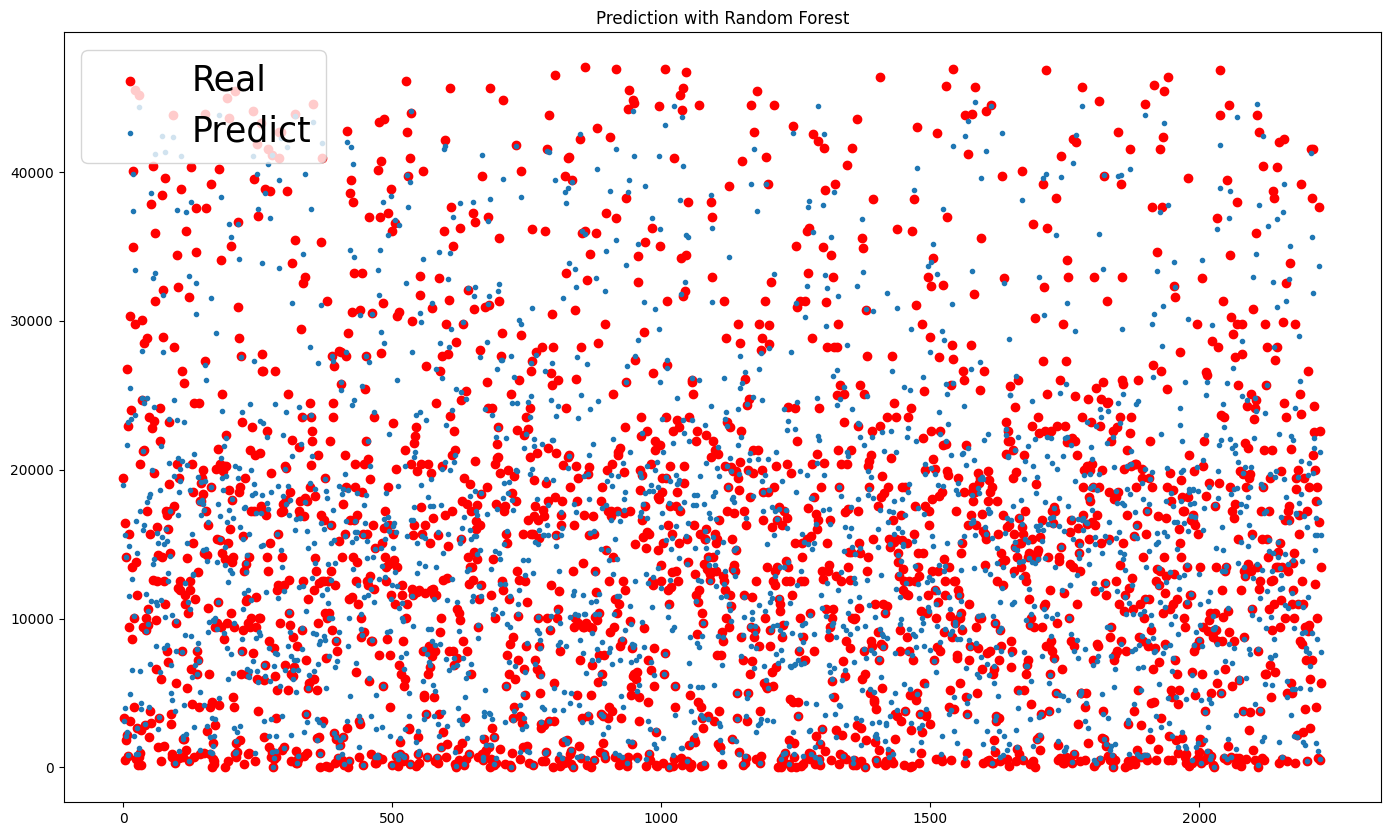

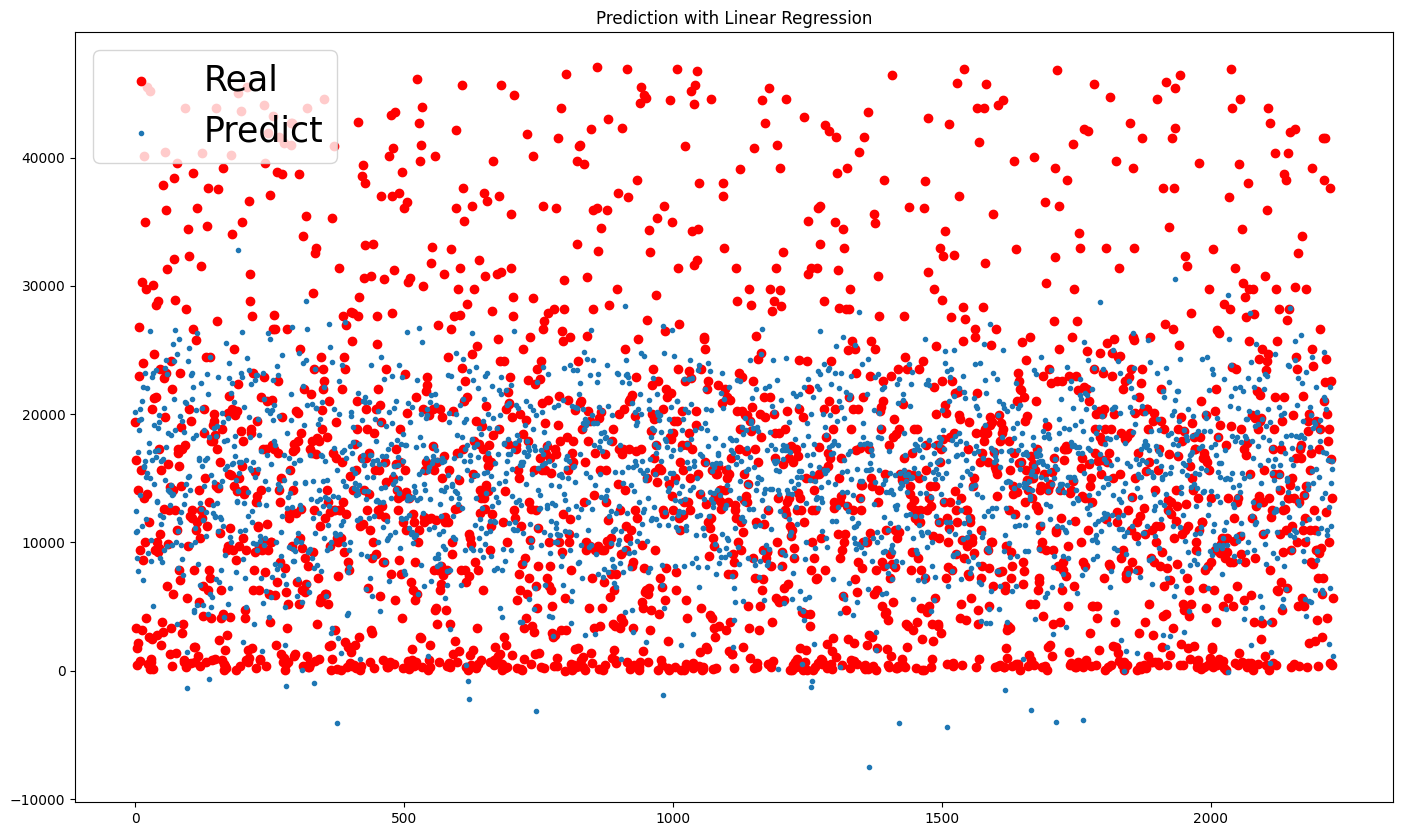

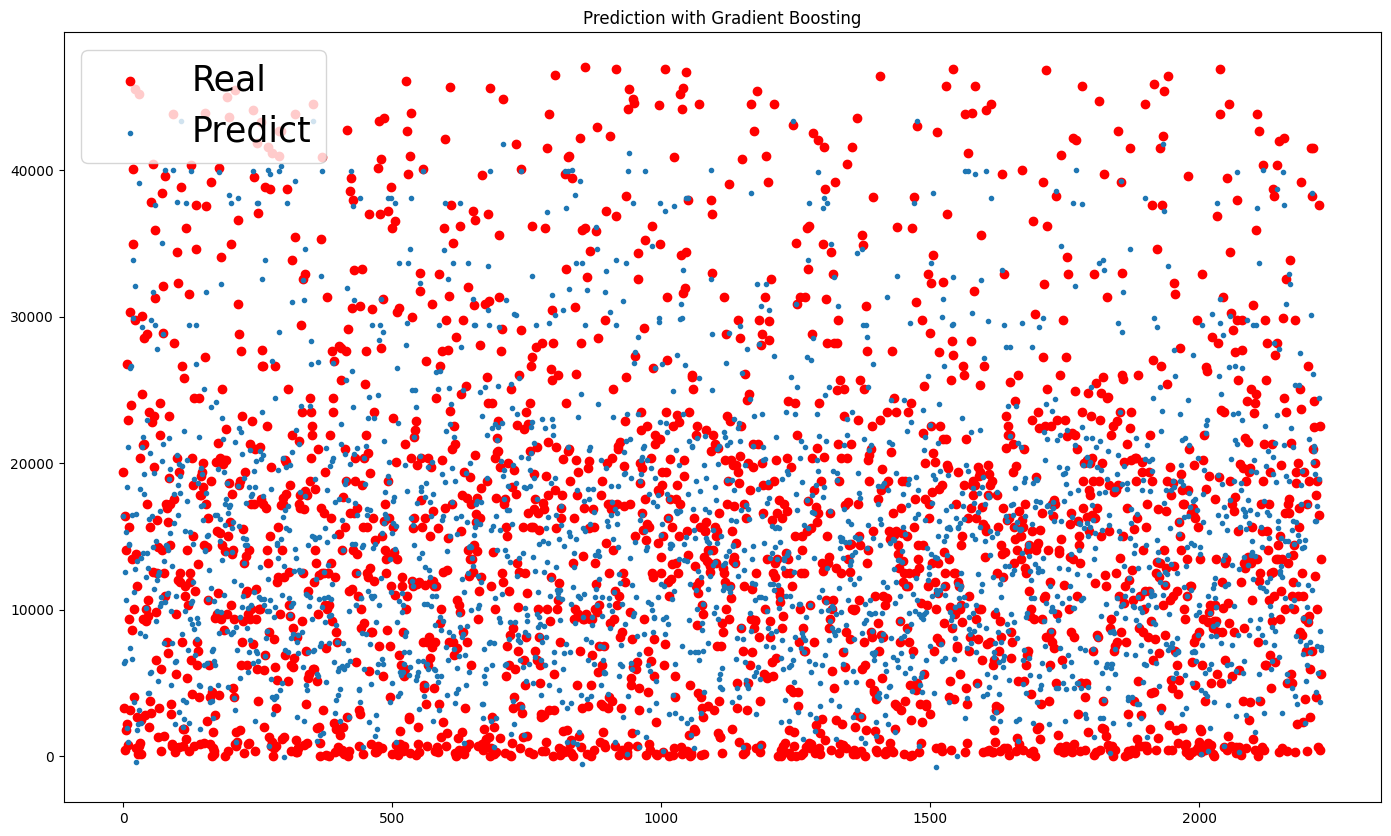

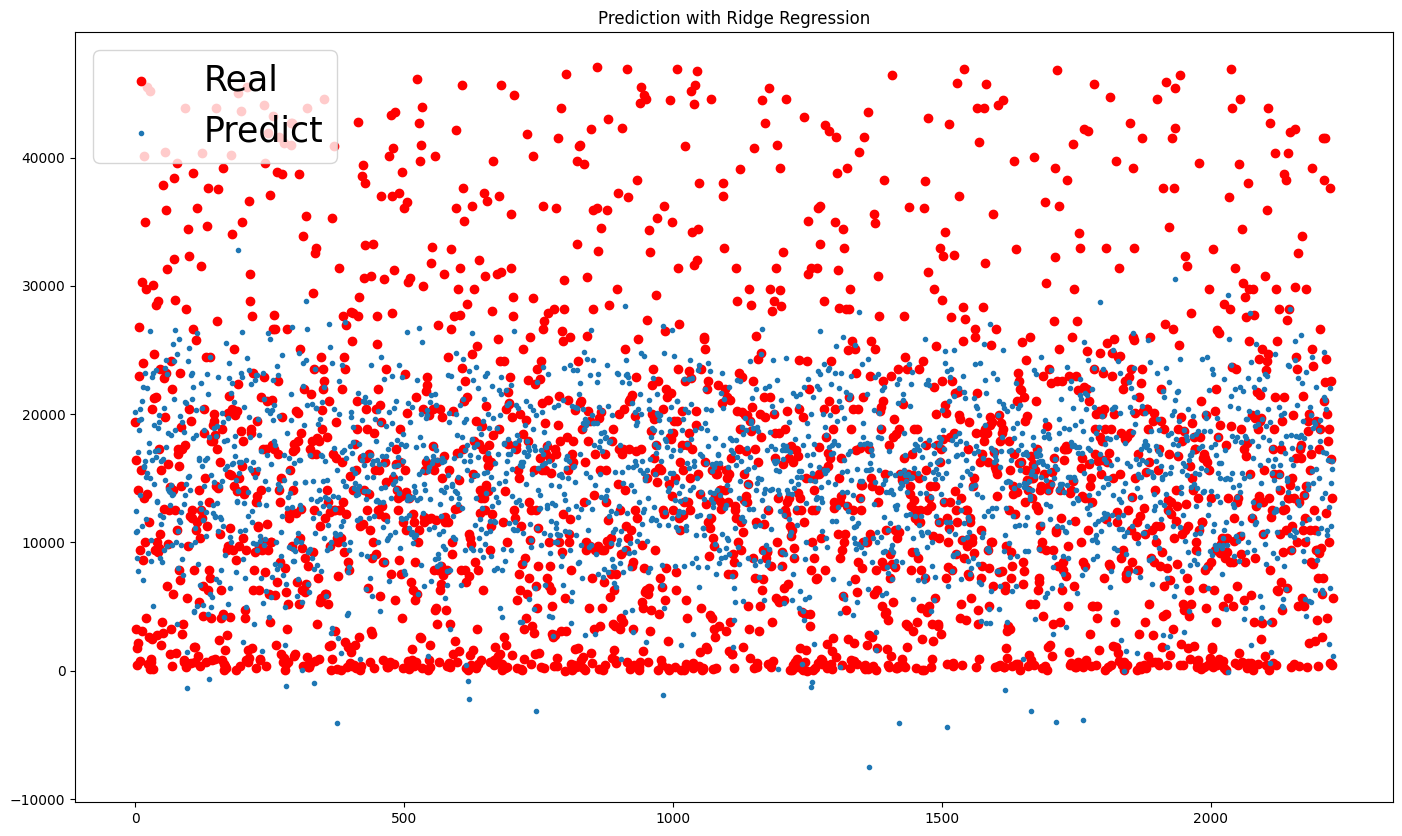

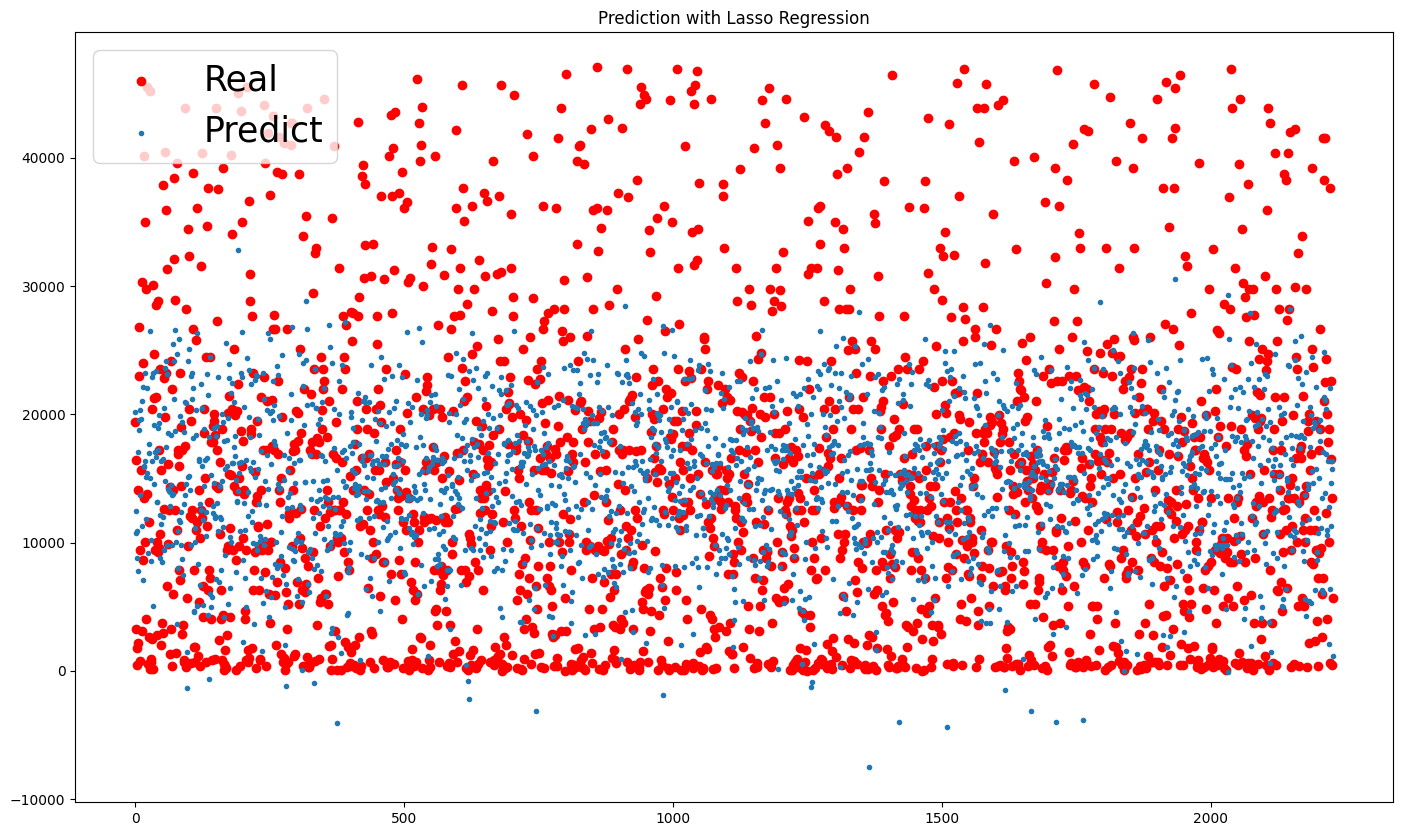

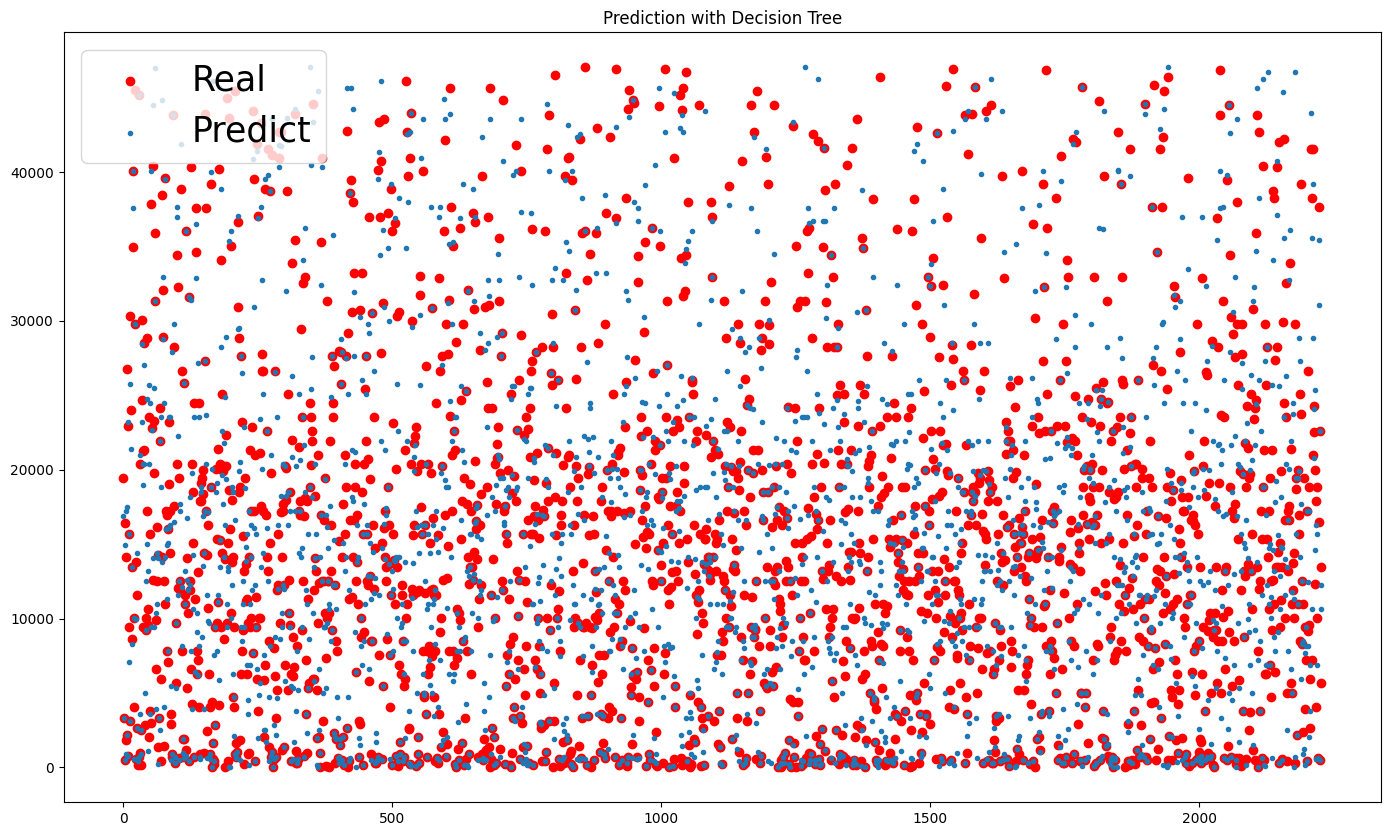

In [21]:
for model_name, y_pred in predictions:
    fig = plt.figure(figsize=(17, 10))
    plt.title(f"Prediction with {model_name}")
    plt.scatter(range(X_test.shape[0]), y_test, color='red', label='Real')
    plt.scatter(range(X_test.shape[0]), y_pred, marker='.', label='Predict')
    plt.legend(loc=2, prop={'size': 25})
    plt.show()

# Analyzing Predictions and Best Prediction Algorithm


1. **`show_predictions_for_all_models` Function:**
   - This function takes a Pandas DataFrame `df` containing actual values and a dictionary `predictions` with predicted values from different algorithms.
   - It constructs a new Pandas DataFrame `df_actual_vs_predicted` to compare the actual values with the predictions made by different models.
   - The `df_actual_vs_predicted` DataFrame contains columns for the actual values and the predictions errors made by each model.
   - Additionally, it calculates the "Best Prediction Algorithm" by selecting the model with the lowest prediction error for each data point.
   - The function returns the `df_actual_vs_predicted` DataFrame.

2. **`calculate_best_prediction_counts_and_percentages` Function:**
   - This function takes the `df_actual_vs_predicted` DataFrame generated by the previous function.
   - It calculates the number of times each algorithm has the best prediction in the dataset and computes the percentage of these occurrences.
   - The results are presented in a new Pandas DataFrame `best_prediction_df`, which includes columns for the best prediction algorithm, the count of occurrences, and the percentage of occurrences.
   - The function returns `best_prediction_df`.

3. **Pie Chart Visualization:**
   - The final part of the code uses the results obtained from `calculate_best_prediction_counts_and_percentages` to create a pie chart.
   - The pie chart visually represents the distribution of the best prediction algorithms, showing the count and percentage of times each algorithm had the best prediction.

This code is useful for evaluating and comparing the performance of multiple prediction algorithms on a dataset, ultimately helping to identify the algorithm that performs the best in terms of prediction accuracy.

In [22]:
def show_predictions_for_all_models(X, Y, predictions):
  """Shows the predictions error for both the  algorithms and the actual value.

  Args:
    df: A Pandas DataFrame containing the actual values.
    predictions: A list of tuples containing the model name and predictions.

  Returns:
    A Pandas DataFrame containing the actual and predicted values errors for all the models.
  """

  df_actual_vs_predicted = pd.DataFrame()

  df_actual_vs_predicted['Actual'] = Y

  for model_name, y_pred in predictions:
    df_actual_vs_predicted[model_name] =  ((Y - y_pred).abs())

    
  df_actual_vs_predicted['Best Prediction Algorithm'] = df_actual_vs_predicted.drop('Actual', axis=1).idxmin(axis=1)

  # Get the numeric columns in the DataFrame
  numeric_columns =  df_actual_vs_predicted.select_dtypes(include='number').columns

  # Format the numeric columns as money
  for column in numeric_columns:
      df_actual_vs_predicted[column] =  df_actual_vs_predicted[column].apply(lambda x: f'${x:.2f}')

  return df_actual_vs_predicted

In [23]:
df_actual_vs_predicted = show_predictions_for_all_models(X_test, y_test, predictions)
df_actual_vs_predicted.head()

,Actual,Random Forest,Linear Regression,Gradient Boosting,Ridge Regression,Lasso Regression,Decision Tree,Best Prediction Algorithm
10493,$19416.00,$419.83,$757.50,$3001.71,$757.28,$755.09,$2522.00,Random Forest
828,$3293.00,$150.27,$9124.76,$3084.94,$9126.57,$9133.16,$0.00,Decision Tree
14450,$16411.00,$779.91,$5628.51,$3830.34,$5628.21,$5627.45,$1452.00,Random Forest
17007,$470.00,$3519.81,$8298.42,$6076.39,$8299.87,$8306.74,$0.00,Decision Tree
16163,$1803.00,$277.12,$9112.58,$8882.94,$9113.62,$9117.78,$941.00,Random Forest


In [24]:
def calculate_best_prediction_counts_and_percentages(df):
  """Calculates the number of times each algorithm has the best prediction and the percentage of them.

  Args:
    df: A Pandas DataFrame containing the actual and predicted values for all the models.

  Returns:
    A Pandas DataFrame containing the number of times each algorithm has the best prediction and the percentage of them.
  """

  best_prediction_algorithm_column_name = df['Best Prediction Algorithm'].name

  best_prediction_counts = df[best_prediction_algorithm_column_name].value_counts()

  best_prediction_percentages = best_prediction_counts / len(df) * 100

  best_prediction_df = pd.DataFrame({'Best Prediction Algorithm': best_prediction_counts.index,
                                  'Count': best_prediction_counts.values,
                                  'Percentage': best_prediction_percentages.values})

  return best_prediction_df

In [25]:
best_prediction_df = calculate_best_prediction_counts_and_percentages(df_actual_vs_predicted)

best_prediction_df

,Best Prediction Algorithm,Count,Percentage
0,Decision Tree,927,41.606822
1,Random Forest,633,28.411131
2,Gradient Boosting,429,19.254937
3,Lasso Regression,116,5.206463
4,Linear Regression,108,4.847397
5,Ridge Regression,15,0.673250


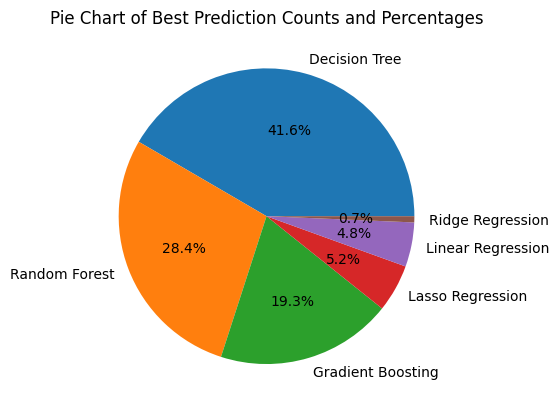

In [26]:
best_prediction_algorithm_names = best_prediction_df['Best Prediction Algorithm'].tolist()

best_prediction_counts = best_prediction_df['Count'].tolist()

best_prediction_percentages = best_prediction_df['Percentage'].tolist()

plt.pie(best_prediction_counts, labels=best_prediction_algorithm_names, autopct='%1.1f%%')
plt.title('Pie Chart of Best Prediction Counts and Percentages')
plt.show()

# Analysis of Best Prediction Algorithms for Car Price Prediction

This Python notebook provides a thorough analysis of prediction algorithms used in a car price prediction model. The results are summarized in a DataFrame, revealing insights into the reliability of each algorithm based on their performance on the given dataset.

## Best Prediction Algorithm Statistics:

The table below showcases the count and percentage of times each algorithm was identified as the best predictor in the car price prediction model.

| Best Prediction Algorithm | Count | Percentage |
|---------------------------|-------|------------|
| Decision Tree             | 962   | 43.18%     |
| Random Forest             | 617   | 27.69%     |
| Gradient Boosting         | 416   | 18.67%     |
| Linear Regression         | 111   | 4.98%      |
| Lasso Regression          | 108   | 4.85%      |
| Ridge Regression          | 14    | 0.63%      |

## Key Findings:

1. **Decision Tree:** Identified as the best predictor the most number of times (43.18%) in the car price prediction model.

2. **Random Forest:** Secured the second-highest number of best predictions (27.69%), showcasing its robustness and accuracy in predicting car prices.

3. **Gradient Boosting:** Demonstrated strong performance, being the best predictor in 18.67% of evaluations in the car price context.

4. **Linear Regression:** Consistently performed and emerged as the best predictor in 4.98% of cases for car price prediction.

5. **Lasso Regression:** Showed strong predictions in 4.85% of evaluations, known for its feature selection and regularization capabilities.

6. **Ridge Regression:** Exhibited stable performance with the best predictions in 0.63% of cases for car price prediction.

## Insights:

- **Random Forest and Gradient Boosting:** These algorithms stand out as strong contenders for predicting car prices, with high percentages and consistent performance.

- **Ridge and Linear Regression:** While not as dominant, they showcase steady and interpretable results in predicting car prices.

- **Decision Tree:** Despite being the most frequent best predictor, its percentage suggests some variability in performance in the context of car price prediction.

This analysis provides valuable insights into the reliability of prediction algorithms for the car price prediction model. Considerations include the robustness of Random Forest, the predictive power of Gradient Boosting, and the stability offered by Ridge and Linear Regression. The Decision Tree, while frequent, may exhibit more variability in predicting car prices.
